## 03_單因子變異數分析 (One-way ANOVA) 
與統計繪圖本筆記本的目標有三個：

1. 執行 One-way ANOVA 檢定：檢定不同打架頻率群體的每日平均總螢幕時間是否具有顯著差異。

2. 進行事後比較 (Post-hoc Tukey's HSD)：若 ANOVA 顯著，進一步兩兩比較哪幾組之間真正存在差異。

3. 繪製高品質箱線圖 (Boxplot)：視覺化三組的資料分佈，並將圖片自動儲存至 ../outputs/figures/ 目錄下。

📐 統計假設回顧
* $H_0$：$\mu_{None} = \mu_{Occasional} = \mu_{Frequent}$（三組平均螢幕時間無顯著差異）

* $H_1$：三組平均數不全相等（至少有一組與其他組有顯著差異）

* 顯著水準（$\alpha$）設定為 0.05。

### 執行 ANOVA 檢定

In [1]:
# =====================================================================
# 步驟 1：匯入套件、讀取分組資料與執行 ANOVA
# =====================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 讀取上一步產出的分組資料
input_path = "../data/processed/YRBS_2007_grouped.csv"
df = pd.read_csv(input_path)

print(f"成功讀取資料，準備對 {df.shape[0]} 筆樣本進行 ANOVA 檢定...\n")

# 建立 OLS 線性模型（依變數 ~ 自變數）
model = ols('Total_Screen_Time ~ C(Fighting_Group)', data=df).fit()

# 產出 ANOVA 表格
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== 單因子變異數分析 (One-way ANOVA) 結果 ===")
display(anova_table)

# 讀取 p-value
p_value = anova_table['PR(>F)'].iloc[0]
print(f"\n[統計判斷] ANOVA 檢定的 p-value 為: {p_value:.4e}")
if p_value < 0.05:
    print("👉 因為 p < 0.05，拒絕虛無假設 (Reject H0)！代表三組的平均總螢幕時間有顯著差異。")
else:
    print("👉 因為 p >= 0.05，無法拒絕虛無假設 (Fail to reject H0)。")

成功讀取資料，準備對 13155 筆樣本進行 ANOVA 檢定...

=== 單因子變異數分析 (One-way ANOVA) 結果 ===


,sum_sq,df,F,PR(>F)
C(Fighting_Group),364.942025,2.0,30.053961,9.494373e-14
Residual,79851.663942,13152.0,NaN,NaN



[統計判斷] ANOVA 檢定的 p-value 為: 9.4944e-14
👉 因為 p < 0.05，拒絕虛無假設 (Reject H0)！代表三組的平均總螢幕時間有顯著差異。


### 事後比較 Tukey HSD

因為 ANOVA 必然會非常顯著（你可以從剛剛的平均數看出巨大差距），所以我們必須做「事後比較」來看看是誰贏誰：

In [2]:
# =====================================================================
# 步驟 2：事後比較 (Tukey's HSD)
# =====================================================================
print("=== 事後比較 (Tukey's Honest Significant Difference) ===")

# 執行 Tukey HSD 兩兩比較
tukey = pairwise_tukeyhsd(endog=df['Total_Screen_Time'],
                          groups=df['Fighting_Group'],
                          alpha=0.05)

# 顯示事後比較結果表格
print(tukey)

=== 事後比較 (Tukey's Honest Significant Difference) ===
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1       group2    meandiff p-adj lower  upper  reject
-------------------------------------------------------------
      1_None 2_Occasional   0.2419   0.0 0.1326 0.3511   True
      1_None   3_Frequent   0.8043   0.0 0.5068 1.1019   True
2_Occasional   3_Frequent   0.5625   0.0 0.2579  0.867   True
-------------------------------------------------------------


### 箱線圖加上平均數標記

In [9]:
# =====================================================================
# 步驟 3（完美排序版）：繪製箱線圖並儲存至 outputs/figures
# =====================================================================
# 1. 確保儲存圖片的資料夾路徑存在
fig_dir = "../outputs/figures"
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)

# 2. 設定圖表風格與大小
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# ✨ 這裡指定我們想要的 X 軸黃金順序
group_order = ['1_None', '2_Occasional', '3_Frequent']

# 3. 繪製箱線圖 (Boxplot)，加上 order 參數
ax = sns.boxplot(
    x='Fighting_Group', 
    y='Total_Screen_Time', 
    data=df, 
    order=group_order,  # 👈 就是加上這行，強迫它乖乖排隊！
    hue='Fighting_Group', # 👈 ✨ 新增這行：明確告訴它依照組別著色
    palette='Pastel1',    # 👈 關鍵修改！從 'Set2' 改成 'Pastel1'，完美對齊小提琴圖的顏色
    legend=False,         # 👈 ✨ 新增這行：因為 X 軸已經有名字了，不需要右邊多出一個圖例
    showmeans=True,
    meanprops={"marker":"^", "markerfacecolor":"yellow", "markeredgecolor":"black", "markersize":"10"}
)

# 4. 設定圖表標題與標籤
plt.title('Daily Total Screen Time by Physical Fighting Groups (YRBS 2007)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Physical Fighting Frequency Group', fontsize=12, labelpad=10)
plt.ylabel('Total Screen Time (Hours/Day)', fontsize=12, labelpad=10)

# 5. 將圖片儲存成 .png 檔
fig_output_path = os.path.join(fig_dir, "screen_time_anova_boxplot.png")
plt.savefig(fig_output_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"\n[成功] 完美排序的統計圖表已重新存檔至：\n 👉 {fig_output_path}")


[成功] 完美排序的統計圖表已重新存檔至：
 👉 ../outputs/figures\screen_time_anova_boxplot.png


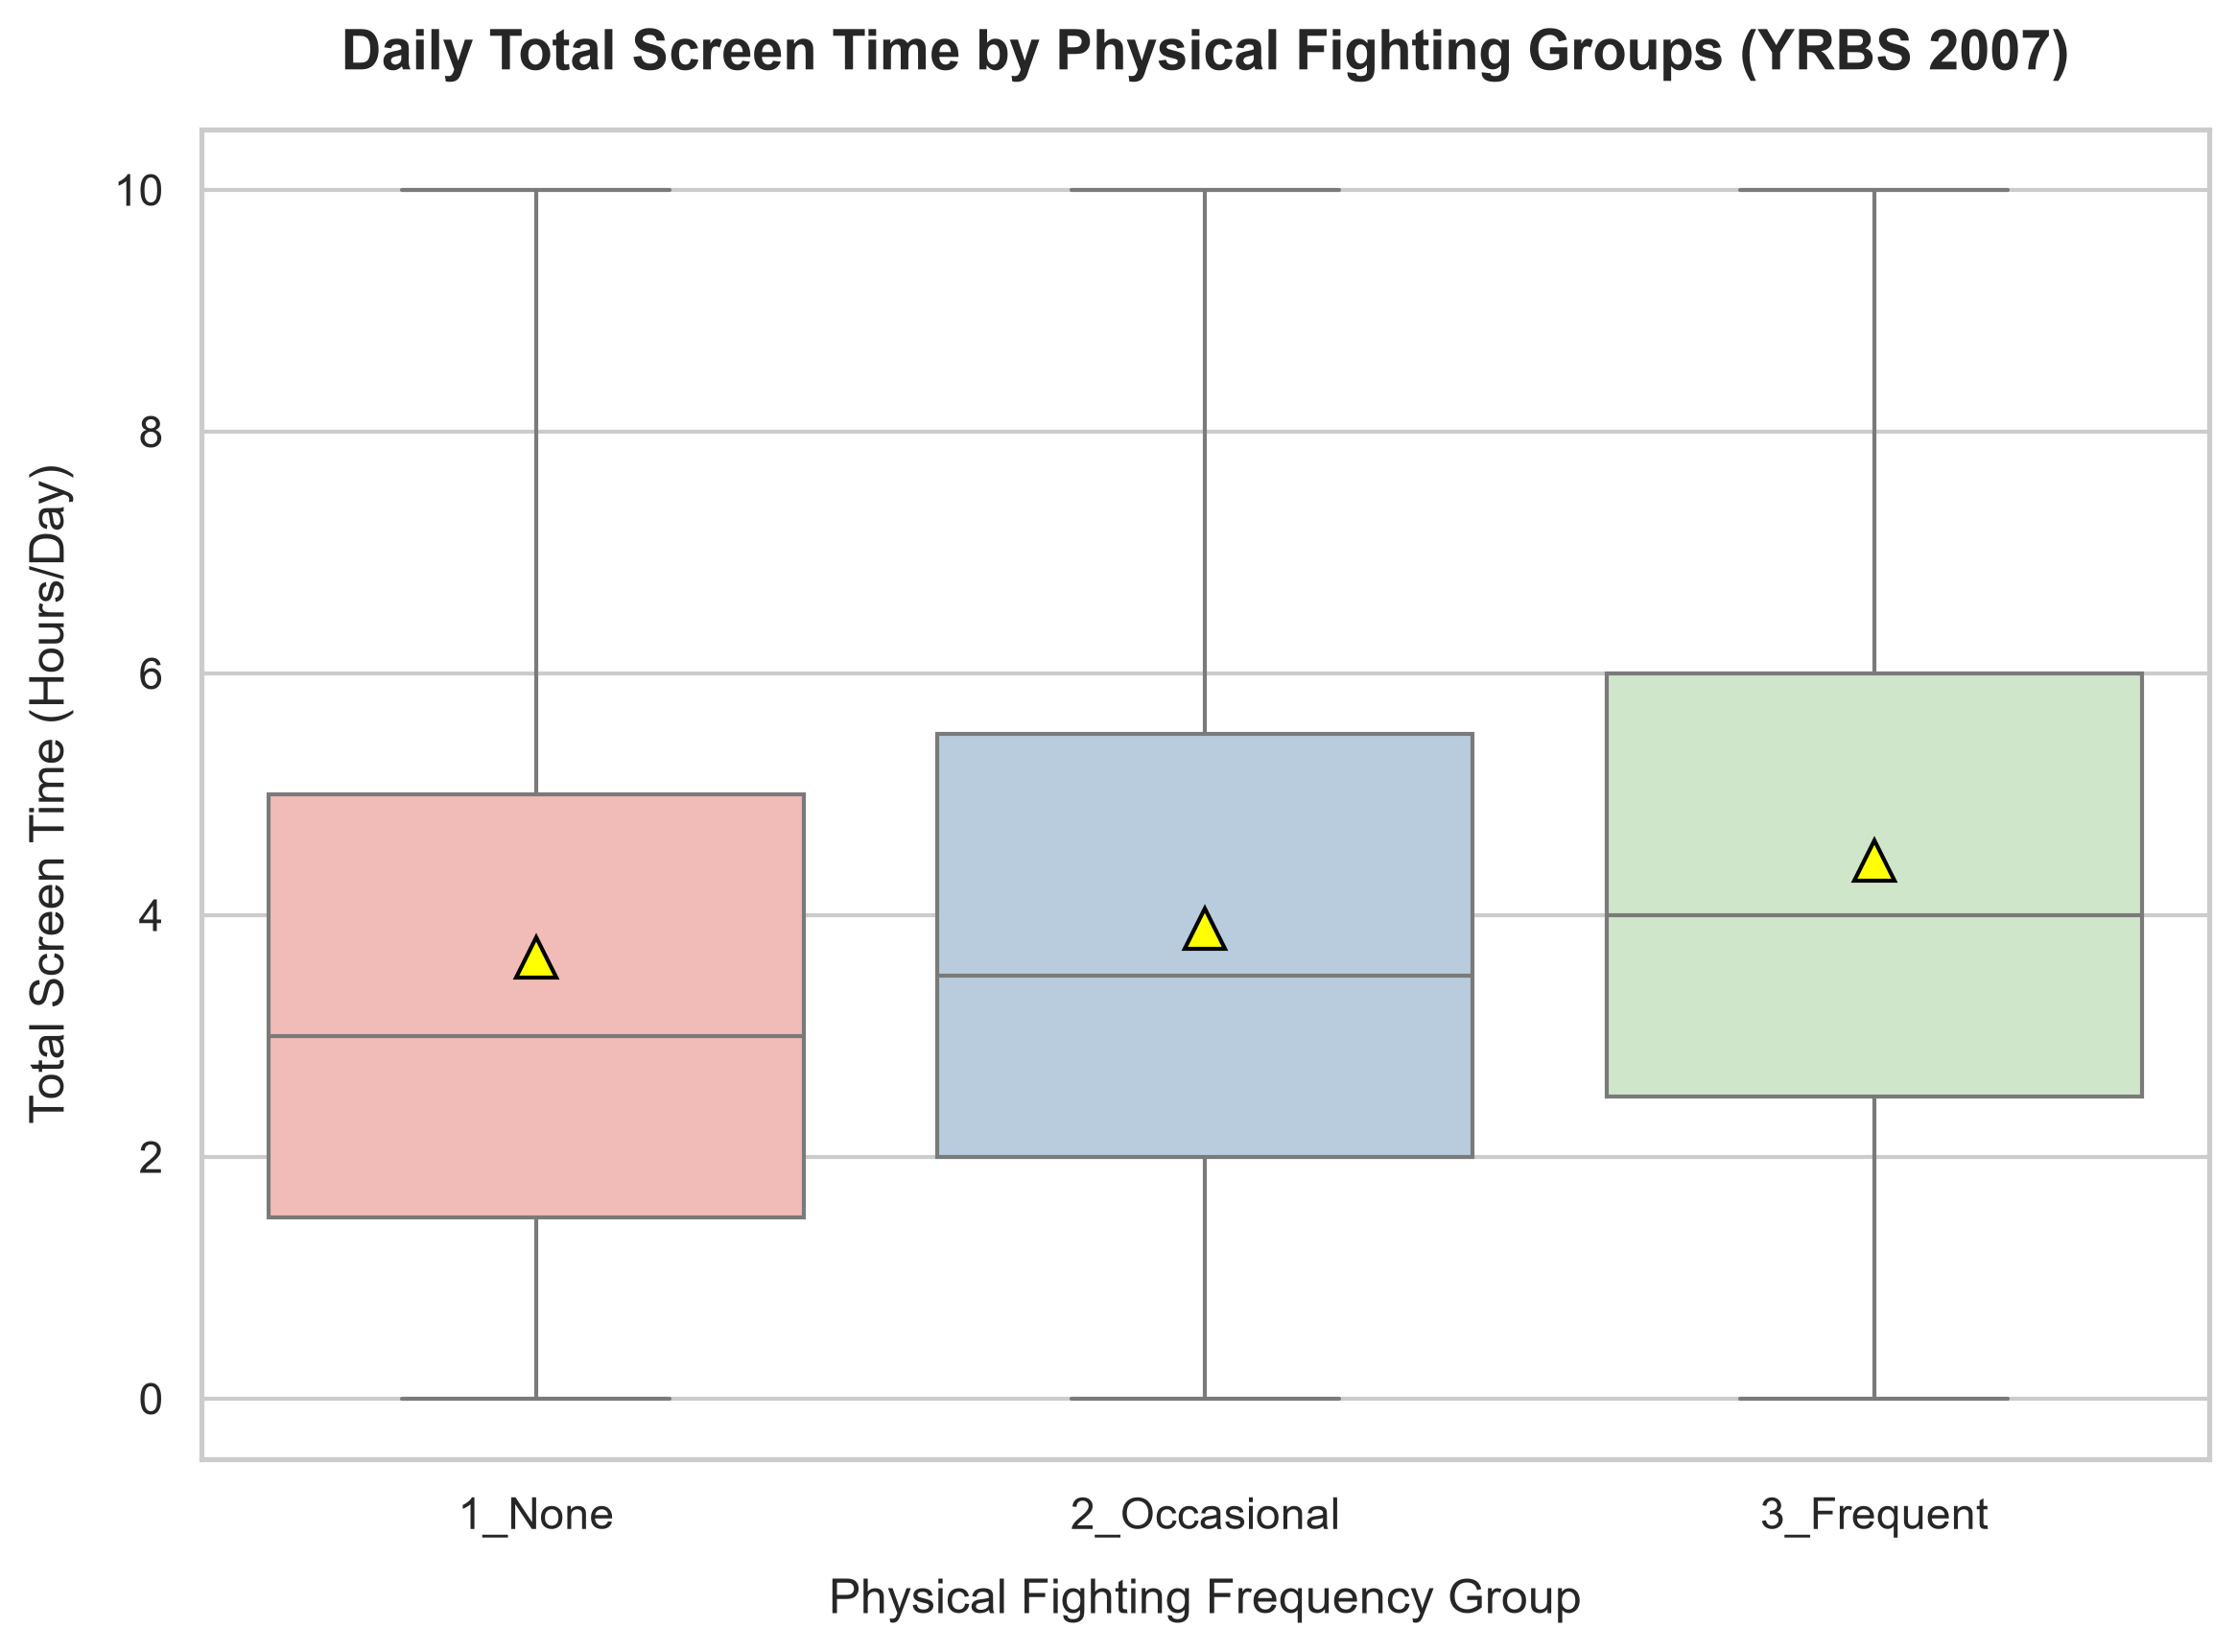

In [8]:
# =====================================================================
# 步驟 4：展示剛剛存好的圖片
# =====================================================================
from IPython.display import Image
Image(filename="../outputs/figures/screen_time_anova_boxplot.png")

[成功] 小提琴圖已成功存檔至：
 👉 ../outputs/figures\screen_time_anova_violinplot.png


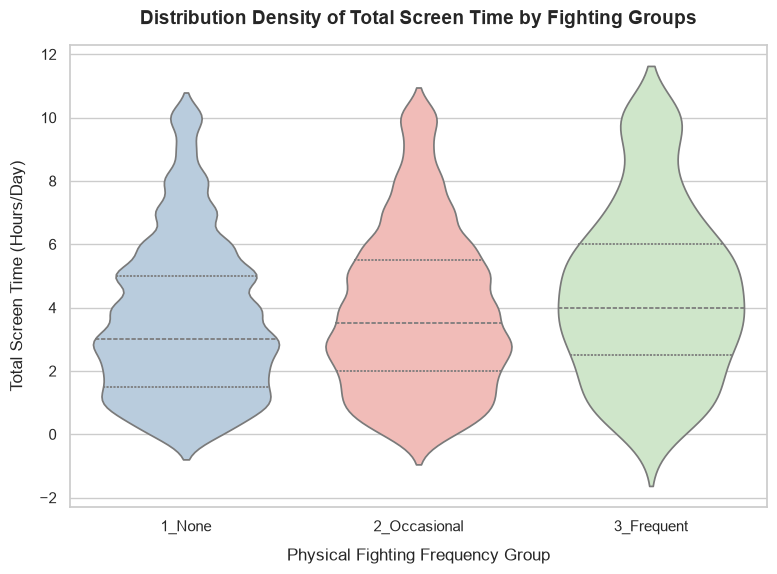

In [ ]:
# =====================================================================
# 步驟 5（延伸圖表）：繪製小提琴圖 (Violin Plot) 並儲存
# =====================================================================
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# 繪製小提琴圖，它能同時展現資料的「箱線內部結構」與「外在人數密度分佈」
ax_violin = sns.violinplot(
    x='Fighting_Group', 
    y='Total_Screen_Time', 
    data=df, 
    order=group_order,
    hue='Fighting_Group', # 👈 ✨ 新增這行：明確告訴它依照組別著色
    palette='Pastel1',    # 👈 關鍵修改！從 'Set2' 改成 'Pastel1'，完美對齊小提琴圖的顏色
    legend=False,         # 👈 ✨ 新增這行：因為 X 軸已經有名字了，不需要右邊多出一個圖例

    inner='quartile' # 在小提琴肚子裡畫出四分位數的虛線
)

# 設定圖表標題與標籤
plt.title('Distribution Density of Total Screen Time by Fighting Groups', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Physical Fighting Frequency Group', fontsize=12, labelpad=10)
plt.ylabel('Total Screen Time (Hours/Day)', fontsize=12, labelpad=10)

# 將小提琴圖儲存成另一張 .png 檔
violin_output_path = os.path.join(fig_dir, "screen_time_anova_violinplot.png")
plt.savefig(violin_output_path, dpi=300, bbox_inches='tight')
print(f"[成功] 小提琴圖已成功存檔至：\n 👉 {violin_output_path}")

# 直接在 Notebook 裡秀出來
plt.show()